# EDA_3rd — OilPrice / VIX 추가 차분 파이프라인

**데이터**: `EDA_2nd_result.csv` (4820행, 13컬럼)  
EDA_2nd 결과, ADF 검정에서 정상으로 판정되어 원본으로 남아있는 두 변수(`OilPrice`, `VIX`)에도 1차 차분을 적용한다.

**근거**
- `OilPrice`: 타겟 변수 → 수익률/변화량 형태로 예측 문제를 정의해야 고정회귀(spurious regression)를 피하고 다른 설명변수와 단위를 맞춤
- `VIX`: ADF 정상이지만 고지속적(highly persistent) 시계열 → 다른 차분된 변수들과 해석의 일관성(레벨↔변화량 혼재 방지)을 위해 차분

| 단계 | 내용 |
|------|------|
| 1 | OilPrice / VIX 1차 차분 적용 |
| 2 | 차분 후 ADF 재검정 (전체 13컬럼) |
| 3 | 다중공선성 검토 — VIF |
| 4 | 상관 히트맵 |
| 5 | `EDA_3rd_result.csv` 저장 |

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ───────────────────────────────
DATA_PATH = '../data/Finance_Final/EDA_2nd_result.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'], index_col='date')

print(f'Shape  : {df.shape}')
print(f'기간   : {df.index.min().date()} ~ {df.index.max().date()}')
print(f'컬럼   : {df.columns.tolist()}')
print(f'\n결측치: \n{df.isnull().sum()}')
print(f'\n기초 통계량:')
display(df.describe().round(3))

Shape  : (4799, 13)
기간   : 2007-02-01 ~ 2026-03-16
컬럼   : ['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TermSpread', 'TreasuryYield', 'FedFundsRate']

결측치: 
OilPrice              0
RealInterestRate      0
CPI                   0
DollarIndex           0
VIX                   0
IndustryProduction    0
CPE                   0
OilInventories        0
OPECProduction        0
OilProduction         0
TermSpread            0
TreasuryYield         0
FedFundsRate          0
dtype: int64

기초 통계량:


,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TermSpread,TreasuryYield,FedFundsRate
count,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000,4799.000
mean,72.694,-0.002,0.550,0.005,19.841,0.014,24.406,159.136,11.552,19.204,0.000,-0.000,-0.006
std,21.724,0.201,0.764,0.371,8.777,1.225,152.422,4799.068,582.282,178.286,0.041,0.058,0.190
min,-36.980,-0.656,-3.842,-2.605,9.140,-12.846,-1450.500,-17049.000,-6008.553,-1500.000,-0.280,-0.510,-0.960
25%,56.220,-0.119,0.184,-0.191,14.070,-0.304,2.600,-3115.000,-175.341,-27.000,-0.020,-0.030,-0.020
50%,71.760,0.004,0.565,-0.000,17.500,0.099,21.900,334.000,44.013,12.000,0.000,0.000,0.010
75%,89.080,0.101,0.880,0.200,22.790,0.460,47.500,2953.000,238.280,100.000,0.020,0.030,0.030
max,145.310,0.639,3.659,2.238,82.690,5.633,981.900,21563.000,2033.711,1200.000,0.420,0.290,0.700


## 1. OilPrice / VIX 1차 차분 적용

EDA_2nd 결과 11개 비정상 변수는 이미 주기별 차분이 적용되었다.
이번에는 남아있는 `OilPrice`와 `VIX`에 1차 차분을 추가로 적용한다.

원본 shape : (4799, 13)
차분 후    : (4798, 13)
차분 적용: ['OilPrice', 'VIX']

✓ 그래프 저장: diff3_oil_vix.png


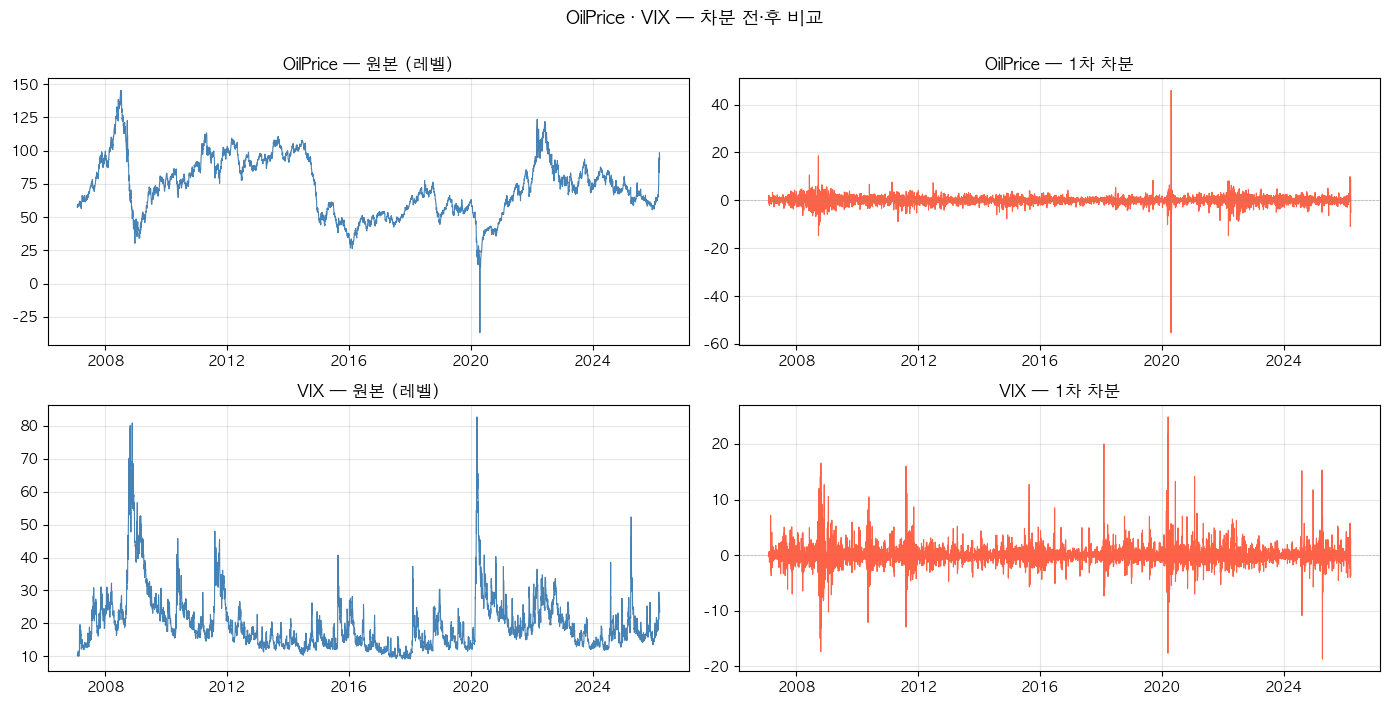

In [6]:
# ── 추가 차분 대상 컬럼 ─────────────────────────────
extra_diff_cols = ['OilPrice', 'VIX']

df_diff = df.copy()
for col in extra_diff_cols:
    df_diff[col] = df[col].diff(1)

# 첫 행 NaN 제거
df_diff = df_diff.dropna()

print(f'원본 shape : {df.shape}')
print(f'차분 후    : {df_diff.shape}')
print(f'차분 적용: {extra_diff_cols}')

# ── 차분 전·후 비교 시각화 (OilPrice, VIX) ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for i, col in enumerate(extra_diff_cols):
    axes[i, 0].plot(df.index, df[col], color='steelblue', linewidth=0.8)
    axes[i, 0].set_title(f'{col} — 원본 (레벨)', fontweight='bold')
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(df_diff.index, df_diff[col], color='tomato', linewidth=0.8)
    axes[i, 1].axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    axes[i, 1].set_title(f'{col} — 1차 차분', fontweight='bold')
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('OilPrice · VIX — 차분 전·후 비교', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../outputs/EDA/diff3_oil_vix.png', dpi=300, bbox_inches='tight')
print('\n✓ 그래프 저장: diff3_oil_vix.png')
plt.show()

## 2. 차분 후 ADF 재검정

전체 13개 컬럼에 대해 ADF 검정을 다시 수행하여 모두 정상 시계열로 변환되었는지 확인한다.

In [7]:
def run_adf(series, col_name, alpha=0.05):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs, crit = result[0], result[1], result[2], result[3], result[4]
    return {
        'Column'    : col_name,
        'ADF Stat'  : round(stat, 4),
        'p-value'   : round(pval, 4),
        'Lags Used' : lags,
        'Obs'       : nobs,
        'Crit 1%'   : round(crit['1%'], 3),
        'Crit 5%'   : round(crit['5%'], 3),
        'Crit 10%'  : round(crit['10%'], 3),
        'Stationary': pval < alpha,
    }

adf_results = [run_adf(df_diff[col], col) for col in df_diff.columns]
adf_df = pd.DataFrame(adf_results).set_index('Column')

print('=' * 70)
print('ADF 재검정 결과 — OilPrice/VIX 차분 후 (alpha=0.05)')
print('=' * 70)
display(adf_df.style
    .applymap(lambda v: 'background-color: #d4edda' if v is True  else
                        'background-color: #f8d7da' if v is False else '',
              subset=['Stationary'])
    .format({'ADF Stat': '{:.4f}', 'p-value': '{:.4f}',
             'Crit 1%': '{:.3f}', 'Crit 5%': '{:.3f}', 'Crit 10%': '{:.3f}'})
)

still_non_stationary = adf_df[adf_df['Stationary'] == False].index.tolist()
if still_non_stationary:
    print(f'\n⚠ 여전히 비정상: {still_non_stationary}')
else:
    print('\n✓ 모든 컬럼이 정상 시계열로 변환되었습니다.')

ADF 재검정 결과 — OilPrice/VIX 차분 후 (alpha=0.05)


,ADF Stat,p-value,Lags Used,Obs,Crit 1%,Crit 5%,Crit 10%,Stationary
Column,,,,,,,,
OilPrice,-10.7179,0.0000,28,4769,-3.432,-2.862,-2.567,True
RealInterestRate,-9.8874,0.0000,23,4774,-3.432,-2.862,-2.567,True
CPI,-6.7778,0.0000,22,4775,-3.432,-2.862,-2.567,True
DollarIndex,-11.1990,0.0000,29,4768,-3.432,-2.862,-2.567,True
VIX,-24.0155,0.0000,9,4788,-3.432,-2.862,-2.567,True
IndustryProduction,-9.5971,0.0000,24,4773,-3.432,-2.862,-2.567,True
CPE,-11.5805,0.0000,32,4765,-3.432,-2.862,-2.567,True
OilInventories,-10.7733,0.0000,28,4769,-3.432,-2.862,-2.567,True
OPECProduction,-10.8803,0.0000,32,4765,-3.432,-2.862,-2.567,True



✓ 모든 컬럼이 정상 시계열로 변환되었습니다.


## 3. 다중공선성 검토 — VIF

이제 전체 13개 컬럼이 일관되게 차분된 형태이므로, 전체 변수를 대상으로 VIF를 계산한다.

- **VIF < 5**: 양호  
- **5 ≤ VIF < 10**: 주의  
- **VIF ≥ 10**: 심각

  VIF — 전체 13컬럼 (차분 통일 후)


Column,VIF,판정
CPE,3.3500,✅ 양호 (<5)
IndustryProduction,2.5697,✅ 양호 (<5)
OPECProduction,1.5136,✅ 양호 (<5)
TreasuryYield,1.4401,✅ 양호 (<5)
TermSpread,1.3407,✅ 양호 (<5)
CPI,1.2138,✅ 양호 (<5)
VIX,1.1472,✅ 양호 (<5)
FedFundsRate,1.1465,✅ 양호 (<5)
DollarIndex,1.1090,✅ 양호 (<5)
OilPrice,1.0985,✅ 양호 (<5)



심각 (VIF≥10)   0개: []
주의 (5≤VIF<10) 0개: []
양호 (VIF<5)    13개: ['CPE', 'IndustryProduction', 'OPECProduction', 'TreasuryYield', 'TermSpread', 'CPI', 'VIX', 'FedFundsRate', 'DollarIndex', 'OilPrice', 'OilProduction', 'OilInventories', 'RealInterestRate']

✓ 그래프 저장: diff3_vif.png


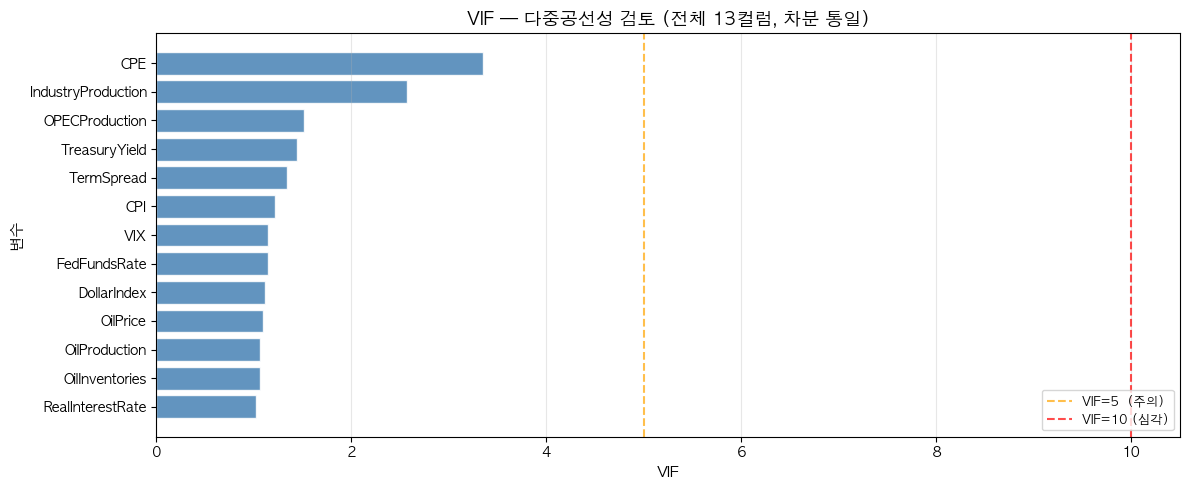

In [8]:
X = df_diff.dropna()
X_vals = X.values

vif_df = pd.DataFrame({
    'Column': X.columns,
    'VIF'   : [variance_inflation_factor(X_vals, i) for i in range(X_vals.shape[1])],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_label(v):
    if v >= 10: return '⚠️  심각 (≥10)'
    elif v >= 5: return '⚡  주의 (5~10)'
    else:        return '✅  양호 (<5)'

vif_df['판정'] = vif_df['VIF'].apply(vif_label)

print('=' * 60)
print('  VIF — 전체 13컬럼 (차분 통일 후)')
print('=' * 60)
display(vif_df.style
    .applymap(lambda v: 'background-color: #f8d7da' if '심각' in str(v) else
                        'background-color: #fff3cd' if '주의' in str(v) else
                        'background-color: #d4edda' if '양호' in str(v) else '',
              subset=['판정'])
    .format({'VIF': '{:.4f}'})
    .hide(axis='index')
)

serious = vif_df[vif_df['VIF'] >= 10]['Column'].tolist()
caution = vif_df[(vif_df['VIF'] >= 5) & (vif_df['VIF'] < 10)]['Column'].tolist()
good    = vif_df[vif_df['VIF'] < 5]['Column'].tolist()

print(f'\n심각 (VIF≥10)   {len(serious)}개: {serious}')
print(f'주의 (5≤VIF<10) {len(caution)}개: {caution}')
print(f'양호 (VIF<5)    {len(good)}개: {good}')

# ── 시각화 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['tomato' if v >= 10 else 'gold' if v >= 5 else 'steelblue'
          for v in vif_df['VIF']]
ax.barh(vif_df['Column'], vif_df['VIF'], color=colors, alpha=0.85, edgecolor='white', linewidth=1)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF=5  (주의)', alpha=0.7)
ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF=10 (심각)', alpha=0.7)
ax.set_xlabel('VIF', fontsize=11, fontweight='bold')
ax.set_ylabel('변수', fontsize=11, fontweight='bold')
ax.set_title('VIF — 다중공선성 검토 (전체 13컬럼, 차분 통일)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/EDA/diff3_vif.png', dpi=300, bbox_inches='tight')
print('\n✓ 그래프 저장: diff3_vif.png')
plt.show()

## 4. 상관 히트맵

✓ 그래프 저장: diff3_corrheatmap.png


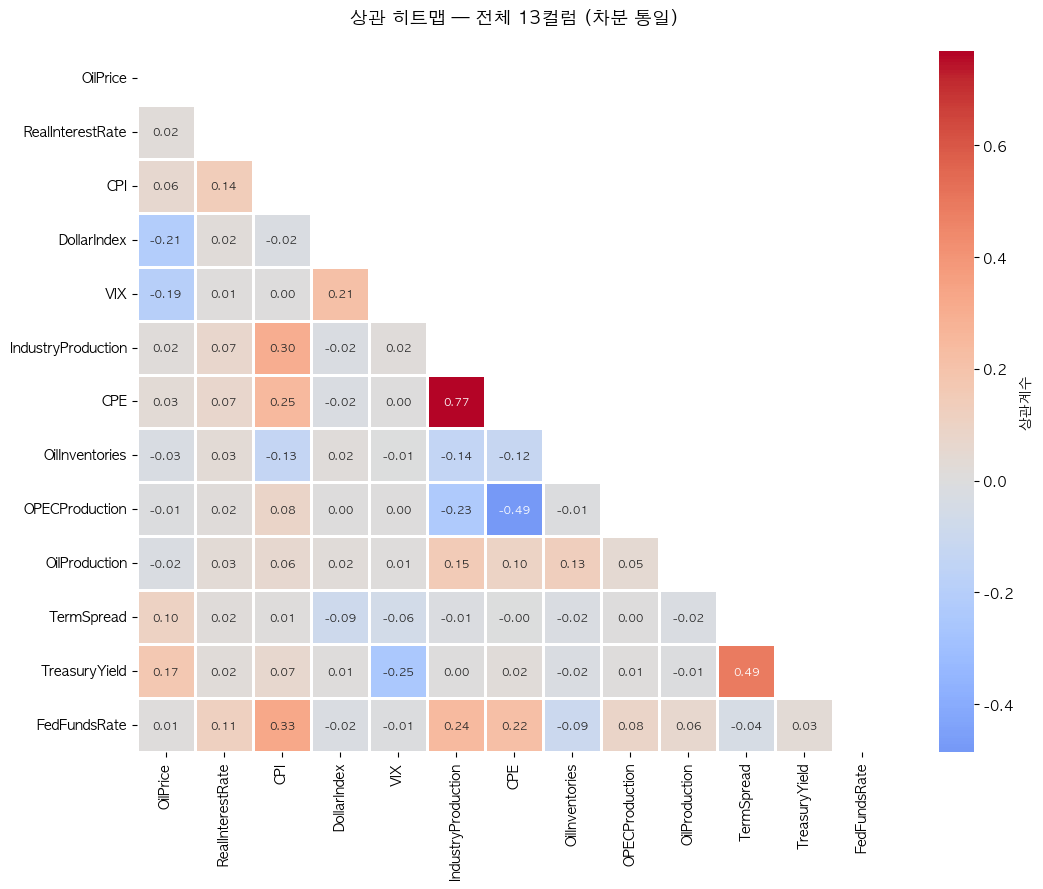

In [9]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df_diff.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.8, ax=ax, cbar_kws={'label': '상관계수'},
            annot_kws={'size': 8, 'weight': 'bold'})
ax.set_title('상관 히트맵 — 전체 13컬럼 (차분 통일)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/EDA/diff3_corrheatmap.png', dpi=300, bbox_inches='tight')
print('✓ 그래프 저장: diff3_corrheatmap.png')
plt.show()

## 5. 결과 저장

In [10]:
df_diff.to_csv('../data/Finance_Final/EDA_3rd_result.csv', index=True)
print(f'✓ 저장 완료: EDA_3rd_result.csv  (shape={df_diff.shape})')

✓ 저장 완료: EDA_3rd_result.csv  (shape=(4798, 13))
